In [5]:
# ==============================
# MULTIPLE LINEAR REGRESSION PROJECT
# ==============================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import jarque_bera

## LOADING DATA

In [21]:
df = pd.read_csv('Mall_Customers_Enhanced.csv')

### DATA PRE-PROCESSING

In [25]:
# Dropping (CustomerID,Age) and Estimated Savings to reduce multicollinearity with other financial variables
df = df.drop(columns=["CustomerID","Age","Estimated Savings (k$)"])

# Converting categorical variables to dummy variables
categorical_columns = ['Age Group', 'Preferred Category', 'Gender']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

## DEFINING FEATURE AND TARGET VARIABLES

In [28]:
X = df.drop("Spending Score (1-100)", axis=1)
y = df["Spending Score (1-100)"]

In [30]:
# Scalling continous variables
continuous_vars = [
    "Annual Income (k$)",
    "Credit Score",
    "Loyalty Years",
]
scaler = StandardScaler()
X[continuous_vars] = scaler.fit_transform(X[continuous_vars])

In [33]:
# ==============================
# TRAIN-TEST SPLIT (80/20)
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add constant for intercept
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Ensure numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)


## MULTIPLE LINEAR REGRESSION

In [37]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Spending Score (1-100)   R-squared:                       0.918
Model:                                OLS   Adj. R-squared:                  0.912
Method:                     Least Squares   F-statistic:                     150.9
Date:                    Thu, 11 Jun 2026   Prob (F-statistic):           1.46e-74
Time:                            10:37:00   Log-Likelihood:                -550.16
No. Observations:                     160   AIC:                             1124.
Df Residuals:                         148   BIC:                             1161.
Df Model:                              11                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## MODEL PERFORMANCE

In [40]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE (TEST SET)")
print("==============================")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MODEL PERFORMANCE (TEST SET)
MSE: 78.8496400489404
RMSE: 8.879731980692908
MAE: 7.173595566628154


# MODEL 2 (REDUCED MODEL)

#### Model was reduced by removing non significant variables from the first model

In [45]:
data = pd.read_csv('Mall_Customers_Enhanced.csv')
data = data.drop(columns=["CustomerID","Gender","Age","Credit Score","Estimated Savings (k$)","Annual Income (k$)"])

In [47]:
# Converting categorical variables to dummy variables
categorical_columns = ['Preferred Category','Age Group']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Spending Score (1-100)          200 non-null    int64
 1   Loyalty Years                   200 non-null    int64
 2   Preferred Category_Electronics  200 non-null    bool 
 3   Preferred Category_Fashion      200 non-null    bool 
 4   Preferred Category_Luxury       200 non-null    bool 
 5   Age Group_26-35                 200 non-null    bool 
 6   Age Group_36-50                 200 non-null    bool 
 7   Age Group_51-65                 200 non-null    bool 
 8   Age Group_65+                   200 non-null    bool 
dtypes: bool(7), int64(2)
memory usage: 4.6 KB


#### DEFINING FEATURE AND TARGET VARIABLES

In [54]:
X1 = data.drop("Spending Score (1-100)", axis=1)
y1 = data["Spending Score (1-100)"]

# Scalling continous variables
continuous_vars = [
    "Loyalty Years",
]
scaler = StandardScaler()
X1[continuous_vars] = scaler.fit_transform(X1[continuous_vars])

In [56]:
# ==============================
# TRAIN-TEST SPLIT (80/20)
# ==============================
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Add constant for intercept
X_train2 = sm.add_constant(X_train2)
X_test2 = sm.add_constant(X_test2)

# Ensure numeric
X_train2 = X_train2.astype(float)
X_test2 = X_test2.astype(float)
y_train2 = y_train2.astype(float)
y_test2 = y_test2.astype(float)

#### MULTIPLE LINEAR REGRESSION

In [61]:
mod = sm.OLS(y_train2, X_train2).fit()
print(mod.summary())

                              OLS Regression Results                              
Dep. Variable:     Spending Score (1-100)   R-squared:                       0.917
Model:                                OLS   Adj. R-squared:                  0.913
Method:                     Least Squares   F-statistic:                     209.4
Date:                    Thu, 11 Jun 2026   Prob (F-statistic):           1.12e-77
Time:                            10:44:13   Log-Likelihood:                -550.98
No. Observations:                     160   AIC:                             1120.
Df Residuals:                         151   BIC:                             1148.
Df Model:                               8                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

#### Applying heteroscedasticity-consistent (HC3) robust standard errors

In [64]:
mod_robust = mod.get_robustcov_results(cov_type='HC3')
print(mod_robust.summary())

                              OLS Regression Results                              
Dep. Variable:     Spending Score (1-100)   R-squared:                       0.917
Model:                                OLS   Adj. R-squared:                  0.913
Method:                     Least Squares   F-statistic:                     214.3
Date:                    Thu, 11 Jun 2026   Prob (F-statistic):           2.24e-78
Time:                            10:46:04   Log-Likelihood:                -550.98
No. Observations:                     160   AIC:                             1120.
Df Residuals:                         151   BIC:                             1148.
Df Model:                               8                                         
Covariance Type:                      HC3                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [66]:
y_pred2 = mod_robust.predict(X_test2)
mse = mean_squared_error(y_test2, y_pred2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test2, y_pred2)

print("\n==============================")
print("MODEL PERFORMANCE (TEST SET)")
print("==============================")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MODEL PERFORMANCE (TEST SET)
MSE: 78.1850249718718
RMSE: 8.842229638042195
MAE: 7.108554221998764


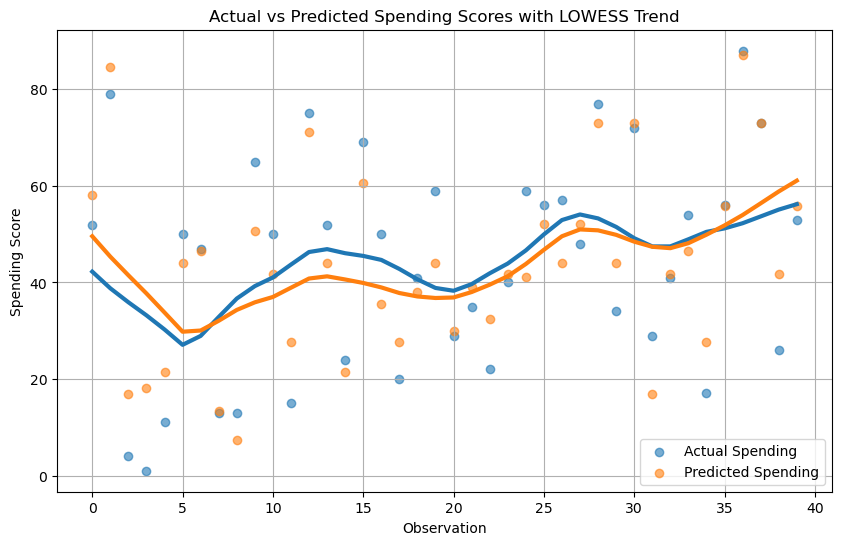

In [68]:
y_actual = y_test2

# Convertion to numpy arrays
y_actual_np = y_actual.values
y_pred_np = y_pred2.values

# Creating index for plotting
x = np.arange(len(y_actual_np))
plt.figure(figsize=(10,6))

# Scatter points
plt.scatter(x, y_actual_np, label="Actual Spending", alpha=0.6)
plt.scatter(x, y_pred_np, label="Predicted Spending", alpha=0.6)

# LOWESS smoothing
lowess_actual = sm.nonparametric.lowess(y_actual_np, x, frac=0.3)
lowess_pred = sm.nonparametric.lowess(y_pred_np, x, frac=0.3)

# Plotting LOWESS lines
plt.plot(lowess_actual[:,0], lowess_actual[:,1], linewidth=3)
plt.plot(lowess_pred[:,0], lowess_pred[:,1], linewidth=3)

plt.xlabel("Observation")
plt.ylabel("Spending Score")
plt.title("Actual vs Predicted Spending Scores with LOWESS Trend")
plt.legend()
plt.grid(True)

plt.show()

In [70]:
residuals = mod_robust.resid
fitted = mod_robust.fittedvalues

# Assumptions

#### 1: Linearity

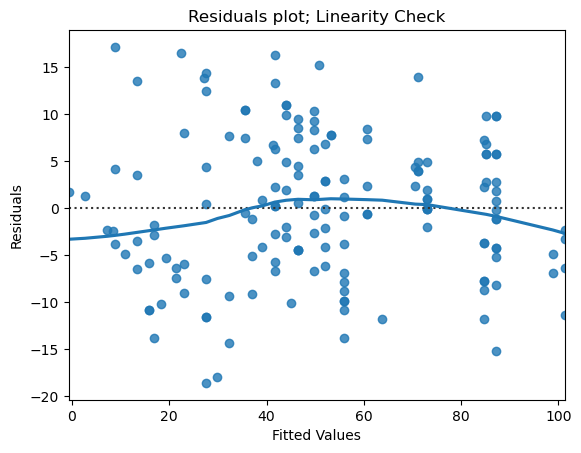

In [75]:
import seaborn as sns

sns.residplot(x=fitted , y=residuals, lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals plot; Linearity Check")
plt.show()

#### 2: Normality

<function matplotlib.pyplot.show(close=None, block=None)>

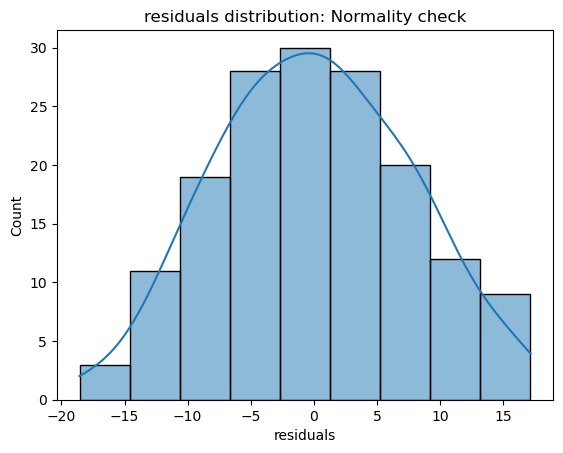

In [78]:
import seaborn as sns
plt.figure()
sns.histplot(residuals, kde = True)
plt.xlabel("residuals")
plt.title("residuals distribution: Normality check")
plt.show

<Figure size 640x480 with 0 Axes>

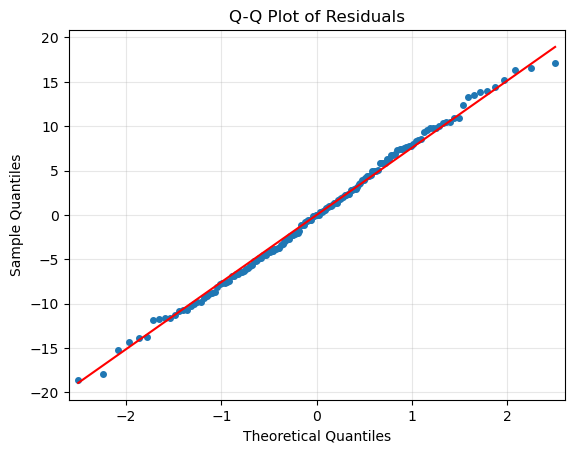

In [80]:
from scipy import stats
from statsmodels.graphics.gofplots import qqplot

# QQ Plot
plt.figure()
qqplot(residuals, line='s', markersize=4)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, alpha=0.3)
plt.show()

In [82]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n1. Normality (Shapiro-Wilk):")
print(f"   Statistic: {shapiro_stat:.4f}")
print(f"   p-value: {shapiro_p:}")
print(f"   {'✓ Normal' if shapiro_p > 0.05 else '⚠ Not normal'}")


1. Normality (Shapiro-Wilk):
   Statistic: 0.9932
   p-value: 0.6626884341239929
   ✓ Normal


#### 3: Homoscedasticity

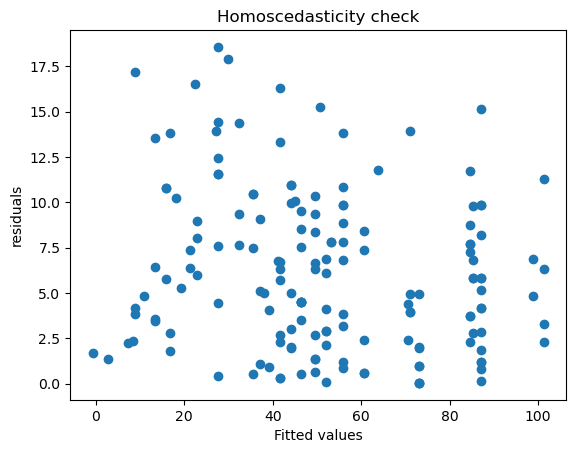

In [85]:
abs_res = np.abs(residuals)
plt.figure()
plt.scatter(fitted, abs_res)
plt.xlabel("Fitted values")
plt.ylabel("residuals")
plt.title("Homoscedasticity check")
plt.show()

In [87]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X_train2)
print(f"\n2. Homoscedasticity (Breusch-Pagan):")
print(f"   p-value: {bp_test[1]}")
print(f"{'✓ Constant variance' if bp_test[1] > 0.05 else '⚠ Non-constant variance'}")


2. Homoscedasticity (Breusch-Pagan):
   p-value: 0.029690031108797817
⚠ Non-constant variance


#### 4: Independence of Errors

In [90]:
from statsmodels.stats.stattools import durbin_watson
durbin_watson(residuals)

2.188020149300731

#### 5: Multicollinearity

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["variable"] = X_train2.columns
vif["VIF"] =  [variance_inflation_factor(X_train2.values,i)
for i in range (X_train2.shape[1])]
vif

,variable,VIF
0,const,23.969462
1,Loyalty Years,3.244847
2,Preferred Category_Electronics,2.746015
3,Preferred Category_Fashion,2.590832
4,Preferred Category_Luxury,4.336725
5,Age Group_26-35,2.397172
6,Age Group_36-50,3.946795
7,Age Group_51-65,4.107233
8,Age Group_65+,3.218141
